In [4]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
print(tf.__version__)

2.19.0


In [5]:
training_data = np.load('TF_dataset.npz')
input_size = 2
output_size = 1

In [29]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation='sigmoid'),
    tf.keras.layers.Dense(10, activation='sigmoid'),
    tf.keras.layers.Dense(output_size)
])
model.compile(optimizer='adafactor', loss='mean_absolute_error')
model.fit(training_data['inputs'], training_data['targets'], epochs=50, verbose=1)

Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 71.7489
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 71.3912
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 70.7234
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 69.5710
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 67.7927
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 65.4175
Epoch 7/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 62.3983
Epoch 8/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 58.5873
Epoch 9/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 54.4010
Epoch 10/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 49.9639
Epoch 11/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 45.3190
Epoch 12/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 40.1499
Epoch 13/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 34.1660
Epoch 14/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 28.7097
Epoch 15/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s

In [30]:
model.layers[0].get_weights()

[array([[-0.4094999 ,  0.04144919,  0.13168015, -0.14603767,  0.29126686,
         -0.15649207,  0.1314235 , -0.13791236, -0.13420835, -0.13202578],
        [-0.22799522,  0.1347635 ,  0.05281804, -0.07530753,  0.17713541,
         -0.09905799,  0.05489063, -0.06167525, -0.06263572, -0.0756864 ]],
       dtype=float32),
 array([ 0.00196532,  0.00122941,  0.00112216,  0.00242703, -0.00017156,
         0.00210591,  0.00097758,  0.00186138,  0.00086943,  0.00109485],
       dtype=float32)]

In [31]:
model.predict_on_batch(training_data['inputs']).round(1)

array([[   3.9],
       [ -99. ],
       [  64.2],
       ...,
       [  83.4],
       [ 103.1],
       [-181.7]], dtype=float32)

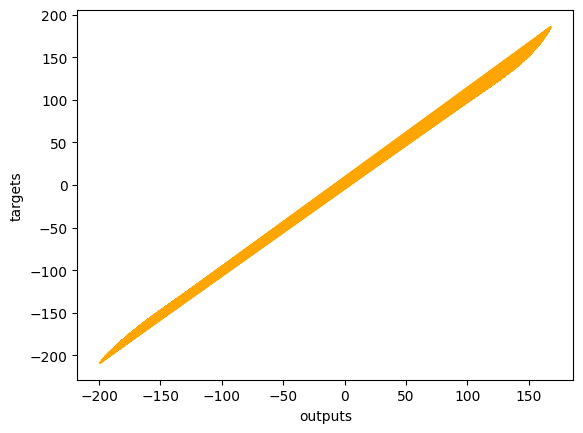

In [32]:
plt.plot(np.squeeze(model.predict_on_batch(training_data['inputs'])),
         np.squeeze(training_data['targets']), color='orange')
plt.xlabel('outputs')
plt.ylabel('targets')
plt.show()